# Модел за откриване на тумор в мозъка

Проектът представлява реализация на конволюционна невронна мрежа, която да може, по дадена снимка на мозък, направена чрез ядрено-магнитен резонанс, да разпознава дали пациентът има тумор и ако да - какъв вид. 

Зареждане на външни зависимости:

In [2]:
import numpy as np
import tensorflow as tf
import keras
import matplotlib.pyplot as plt

2025-01-29 14:28:07.449288: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1738153687.467911   31462 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1738153687.473224   31462 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-29 14:28:07.492154: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Помощни функции за двете използвани активационни функции и техните производни:

In [3]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def softmax_derivative(x):
    return x * (1 - x)

Клас, представляващ конволюционен слой. Класът приема като параметри в контруктора си броят на филтрите и техния размер, каква активационна функция да бъде използвана, както и константа ламбда, необходима за регуларизацията. За инициализиране на теглава е използвана Хи инициализация. За да се предоврати пренагаждане към тренировъчните данни по време на обучение е използвана L2 регуляризация при обновяването на теглата при разпространението на грешката. Идеята на този слой е да се намали размерността и да се извлекат само важните за обучението характеристики.

In [4]:
class ConvolutionalLayer:
    def __init__(self, filters, kernel_size, activation_function, derivative_activation_function, reg_lambda=0.01):
        self.filters = filters
        self.kernel_size = kernel_size
        self.weights = np.random.randn(filters, kernel_size, kernel_size) * np.sqrt(2. / (kernel_size * kernel_size))
        self.activation_function = activation_function
        self.derivative_activation_function = derivative_activation_function
        self.reg_lambda = reg_lambda

    def calculate_output(self, input_data):
        self.input_data = input_data
        output_dim = (input_data.shape[0] - self.kernel_size) + 1
        self.output_data = np.zeros((self.filters, output_dim, output_dim))

        for f in range(self.filters):
            for i in range(output_dim):
                for j in range(output_dim):
                    region = input_data[i:i + self.kernel_size, j:j + self.kernel_size]
                    self.output_data[f, i, j] = np.sum(region * self.weights[f])

        self.output_data = self.activation_function(self.output_data)
        return self.output_data

    def backpropagate_error(self, error, learning_rate):
        derivative = self.derivative_activation_function(self.output_data)
        gradient = error * derivative
        
        d_input = np.zeros_like(self.input_data, dtype=np.float32)
        d_weights = np.zeros_like(self.weights, dtype=np.float32)

        for f in range(self.filters):
            for i in range(error.shape[0]):
                for j in range(error.shape[1]):
                    region = self.input_data[i:i + self.kernel_size, j:j + self.kernel_size]
                    d_weights[f] += region * gradient[f, i, j]

                    flipped_weights = np.flip(self.weights[f])
                    d_input[i:i + self.kernel_size, j:j + self.kernel_size] += flipped_weights * gradient[f, i, j]

        self.weights -= learning_rate * (d_weights + self.reg_lambda * self.weights)

        return d_input

Клас представляващ обединяващ слой. Класът приема като параметри в конструктора си размерът на регионите, както и тяхното отместване. Този слой реализира максимално обединяване, като идеята е да се намали допълнително размерността и да се премахне част от шума. При разпространението на грешката, ако има няколко клетки в един регион, които имат равна стойност на максималната стойност в региона, то грешката се предава на всички такива клетки.

In [5]:
class MaxPoolingLayer:
    def __init__(self, pool_size, stride):
        self.pool_size = pool_size
        self.stride = stride

    def calculate_output(self, input_data):
        self.input_data = input_data
        output_dim = (input_data.shape[1] - self.pool_size) // self.stride + 1
        self.output_data = np.zeros((input_data.shape[0], output_dim, output_dim))

        for f in range(input_data.shape[0]):
            for i in range(output_dim):
                for j in range(output_dim):
                    start_i = i * self.stride
                    start_j = j * self.stride
                    end_i = start_i + self.pool_size
                    end_j = start_j + self.pool_size

                    region = input_data[f, start_i:end_i, start_j:end_j]
                    self.output_data[f, i, j] = np.max(region)

        return self.output_data

    def backpropagate_error(self, error, learning_rate=0):
        d_input = np.zeros_like(self.input_data, dtype=np.float32)

        for f in range(error.shape[0]):
            for i in range(error.shape[1]):
                for j in range(error.shape[2]):
                    start_i = i * self.stride
                    start_j = j * self.stride
                    end_i = start_i + self.pool_size
                    end_j = start_j + self.pool_size

                    region = self.input_data[f, start_i:end_i, start_j:end_j]
                    max_value = np.max(region)

                    for x in range(region.shape[0]):
                        for y in range(region.shape[1]):
                            if region[x, y] == max_value:
                                d_input[f, start_i + x, start_j + y] += error[f, i, j]

        return d_input

Клас представляващ изравняващ (сплескващ) слой. Идеята на този слой е да изравни (или "сплеска") изхода от обединяващия слой, така че от няколко матрици да се получи един вектор, който да може после лесно да се обработи от напълно свързания слой. 

In [6]:
class FlattenLayer:
    def calculate_output(self, input_data):
        self.input_shape = input_data.shape
        return input_data.flatten().reshape(1, -1)

    def backpropagate_error(self, error, learning_rate=0):
        return error.reshape(self.input_shape)

Клас, представляващ изхвърлящ слой. Идеята на този слой е да "изхвърли" част от данните, за да може да се предотврати пренагаждане към тренировъчните данни по време на обучение. Този слой трябва да стои между два напълно свързани слоя в архитектурата на мрежата.

In [7]:
class DropoutLayer:
    def __init__(self, rate):
        self.rate = rate

    def calculate_output(self, input_data):
        self.input_data = input_data
        self.mask = np.random.rand(*input_data.shape) > self.rate
        return input_data * self.mask

    def backpropagate_error(self, error, learning_rate=0):
        return error * self.mask

Клас, представляващ напълно свързан слой. Това е характерният за персептрона слой, който има връзка от всеки входен до всеки изходен неврон. Използвана е нормална инициализация на Хавиер за инициализиране на теглата, както и L2 регуларизация при промяната на теглата по време на разпространението на грешката.

In [8]:
class FullyConnectedLayer:
    def __init__(self, input_size, output_size, activation_function, derivative_activation_function, reg_lambda=0.01):
        self.weights = np.random.randn(input_size, output_size) * np.sqrt(1. / input_size)
        self.bias = np.zeros((1, output_size))
        self.activation_function = activation_function
        self.derivative_activation_function = derivative_activation_function
        self.reg_lambda = reg_lambda

    def calculate_output(self, input_data):
        self.input_data = input_data
        product = np.dot(input_data, self.weights) + self.bias
        self.output_data = self.activation_function(product)

        return self.output_data

    def backpropagate_error(self, error, learning_rate):
        derivative = self.derivative_activation_function(self.output_data)
        gradient = error * derivative

        weight_gradient = np.dot(self.input_data.T, gradient)
        self.weights -= learning_rate * (weight_gradient + self.reg_lambda * self.weights)
        self.bias -= learning_rate * np.sum(gradient, axis=0, keepdims=True)

        return np.dot(gradient, self.weights.T)

Функция, която променя темпото на обучение спрямо епохата. Идеята на тази функция е през определен период от епохи да намаля темпото на обучение с цел по-точното обучение на мрежата.

In [9]:
def update_learning_rate(epoch, initial_learning_rate=0.1, decay_factor=0.75, decay_epoch=7):
    if epoch % decay_epoch == 0 and epoch != 0:
        return initial_learning_rate * decay_factor
    return initial_learning_rate

Клас представляващ една цяла конволюционна невронна мрежа. Класът приема като параметри в конструктора си съответните слоеве на мрежата. По време на обучението, на всяка епоха се изчислява загубата на ентропия и на определен период се намаля темпото на обучение.

In [10]:
class ConvolutionalNeuralNetwork:
    def __init__(self, layers):
        self.layers = layers
        self.losses_by_epochs = []

    def train(self, training_data, targets, epochs, learning_rate):
        for epoch in range(epochs):
            total_loss = 0
            learning_rate = update_learning_rate(epoch, learning_rate)
            for x, y in zip(training_data, targets):
                output = self.forward(x)
                
                loss = -np.mean(np.sum(y * np.log(output + 1e-8), axis=1))
                total_loss += loss
                
                error = output - y
                self.backward(error, learning_rate)

            current_loss = total_loss / len(training_data)
            print(f"Epoch {epoch + 1}/{epochs}, Loss: {current_loss}")
            self.losses_by_epochs.append(current_loss)

    def forward(self, input_data):
        for layer in self.layers:
            input_data = layer.calculate_output(input_data)
        return input_data

    def backward(self, error, learning_rate):
        for layer in reversed(self.layers):
            error = layer.backpropagate_error(error, learning_rate)

Функция за преозмеряване и нормализиране на изображение:

In [11]:
def process_image(size):
    def process_image_inner(image, label):
        image = tf.image.resize(image, (size, size))
        image = tf.squeeze(image)
        image = tf.cast(image, tf.float32) / 255.0
        label = tf.cast(label, tf.float32)
        return image, label
    return process_image_inner

Параметри на модела:

- път до директорията с данните
- оригинален размер на изображенията
- размер на групите от изображение, които да се обработят наведнъж
- брой епохи
- темпо на обучението
- размер на изображенията, с който работи модела

Оригиналните данни могат да се изтеглят от [тук](https://www.kaggle.com/datasets/tombackert/brain-tumor-mri-data)

In [12]:
dataset_directory = "./brain-tumor-mri-data/brain-tumor-mri-dataset/"
initial_image_size = 128
batch_size = 32
epochs = 50
learning_rate = 0.02
image_size = 32

Извличане на тренировъчните и тестовите данни в съотношение 80:20

In [13]:
train_dataset, test_dataset = keras.utils.image_dataset_from_directory(
        directory=dataset_directory,
        image_size=(initial_image_size, initial_image_size),
        color_mode='grayscale',
        batch_size=batch_size,
        labels="inferred",
        label_mode="categorical",
        validation_split=0.2,
        subset="both",
        seed=20,
        shuffle=True
    )

Found 7153 files belonging to 4 classes.
Using 5723 files for training.
Using 1430 files for validation.


2025-01-29 14:28:10.050367: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Създаване на конволюционна невронна мрежа с един конволюционен слой, съдържащ 4 филтъра с размер 3 и използващ ReLU за активационна функция, един обединяващ слой с размер на региона 2 и отместване 2, един изравняващ слой и един напълно свързан слой с 900 входни и 4 изходни параметъра и използващ softmax за активационна функция:

In [14]:
cnn = ConvolutionalNeuralNetwork(layers=[
    ConvolutionalLayer(filters=4, kernel_size=3, activation_function=relu, derivative_activation_function=relu_derivative),
    MaxPoolingLayer(pool_size=2, stride=2), 
    FlattenLayer(),
    FullyConnectedLayer(input_size=900, output_size=4, activation_function=softmax, derivative_activation_function=softmax_derivative),
])

Извличане на 1024 тренировъчни изображения и обучаване на мрежата с тях:

In [15]:
train_images = []
train_labels = []
for image, label in train_dataset.map(process_image(image_size)).shuffle(buffer_size=100).take(32).unbatch():
    train_images.append(image.numpy())
    train_labels.append(label.numpy())

cnn.train(train_images, train_labels, epochs=epochs, learning_rate=learning_rate)

2025-01-29 14:28:10.757301: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 1/50, Loss: 1.1764135089389727
Epoch 2/50, Loss: 1.0079748632889514
Epoch 3/50, Loss: 0.9545295884454055
Epoch 4/50, Loss: 0.9299513793893279
Epoch 5/50, Loss: 0.9167280075992619
Epoch 6/50, Loss: 0.9083463731248991
Epoch 7/50, Loss: 0.9021753627280343
Epoch 8/50, Loss: 0.8786078768814793
Epoch 9/50, Loss: 0.8735813119517037
Epoch 10/50, Loss: 0.8690208308082442
Epoch 11/50, Loss: 0.8647934693537351
Epoch 12/50, Loss: 0.8608534989800166
Epoch 13/50, Loss: 0.8571854133401378
Epoch 14/50, Loss: 0.8537303263662888
Epoch 15/50, Loss: 0.8327369934018783
Epoch 16/50, Loss: 0.8290666430417126
Epoch 17/50, Loss: 0.8258613621920547
Epoch 18/50, Loss: 0.822893934266986
Epoch 19/50, Loss: 0.8201148522034496
Epoch 20/50, Loss: 0.8174984500639003
Epoch 21/50, Loss: 0.8150308034909753
Epoch 22/50, Loss: 0.7973223534370232
Epoch 23/50, Loss: 0.7944608373501517
Epoch 24/50, Loss: 0.7919572465958219
Epoch 25/50, Loss: 0.7896333004616184
Epoch 26/50, Loss: 0.7874506938151793
Epoch 27/50, Loss: 0.7

Извличане на 256 тестови изображения и изчисляване на точността на модела спрямо тях:

In [47]:
test_images = []
test_labels = []
for image, label in test_dataset.map(process_image(image_size)).shuffle(buffer_size=100).take(8).unbatch():
    test_images.append(image.numpy())
    test_labels.append(label.numpy())

test_images = np.array(test_images)
test_labels = np.array(test_labels)
    
predictions = []
for image in test_images:
    predictions.append(np.argmax(cnn.forward(image), axis=1)[0])
labels = np.argmax(test_labels, axis=1)
predictions = np.array(predictions)

accuracy = 0
for pred, true_label in zip(predictions, labels):
    if pred == true_label:
        accuracy += 1

accuracy = accuracy / len(labels)
print(f"Finished with accuracy of {accuracy * 100}%")

Finished with accuracy of 75.390625%


Графика на промяната на загубата на ентропия по време на обучение:

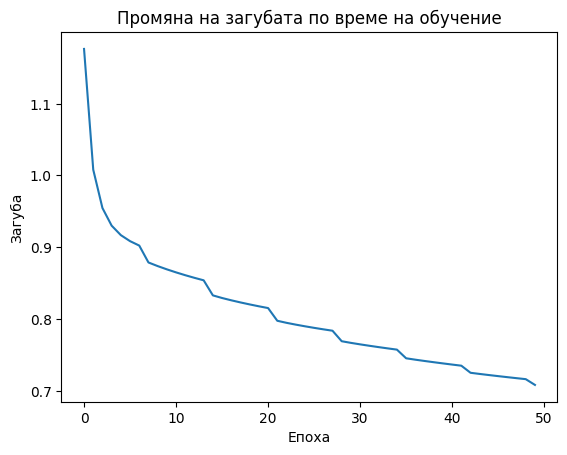

In [17]:
plt.plot(range(epochs), cnn.losses_by_epochs)
plt.title("Промяна на загубата по време на обучение")
plt.xlabel("Епоха")
plt.ylabel("Загуба")
plt.show()

Няколко примерни резултата:

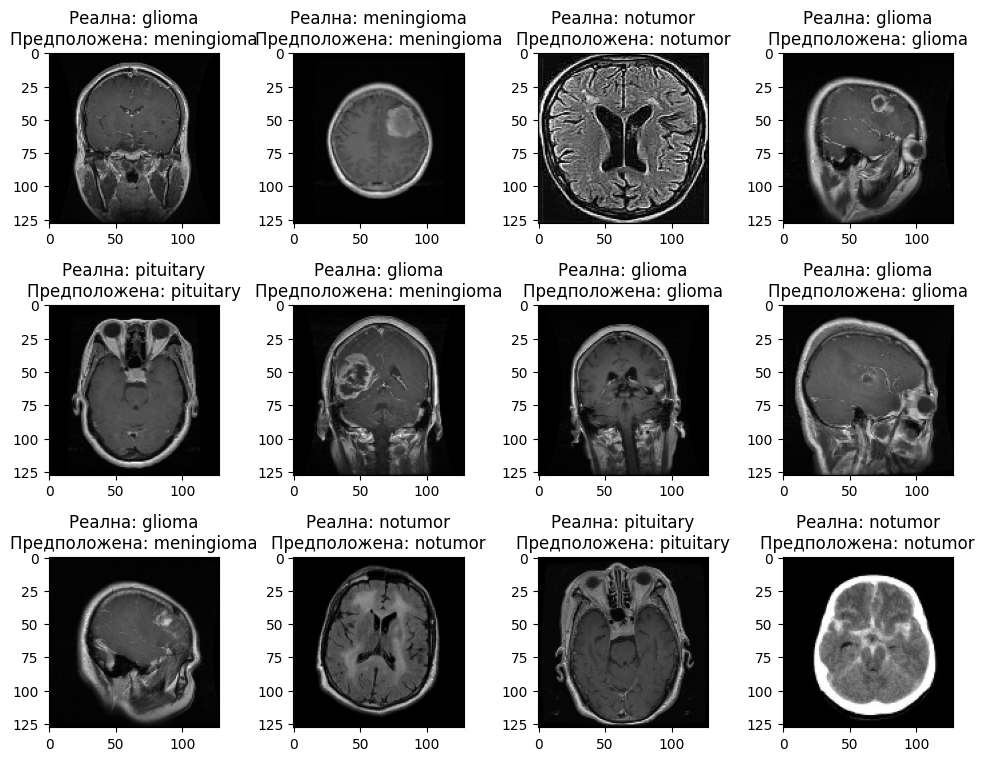

In [64]:
plt.figure(figsize=(10, 10))

for i, (image, label) in enumerate(test_dataset.shuffle(buffer_size=100).take(1).unbatch().take(12)):
    actual_label = train_dataset.class_names[np.argmax(label)]
    image = image.numpy()
                
    plt.subplot(4, 4, i + 1)
    plt.imshow(image, cmap="gray")
        
    processed_image, _ = process_image(image_size)(image, label)
    predictions = cnn.forward(processed_image)
    prediction = np.argmax(predictions[0])
        
    if prediction == 0:
        predicted_label = 'glioma'
    elif prediction == 1:
        predicted_label = 'meningioma'
    elif prediction == 2:
        predicted_label = 'notumor'
    elif prediction == 3:
        predicted_label ='pituitary'
        
    plt.title(f"Реална: {actual_label}\nПредположена: {predicted_label}")
    plt.tight_layout()